In [ ]:
# %pip install torch numpy matplotlib
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.datasets import fetch_olivetti_faces
from torch import nn
from torchvision import transforms

SEED, STEPS, BATCH_SIZE = 42, 1200, 150
STEP_RECORD = 100
NOISE = 0.06  # Шум в координатах после деления на 10.
torch.manual_seed(SEED)
torch.set_num_threads(2)  # Для маленьких MLP на CPU.
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print(f"PyTorch {torch.__version__} | CPU | seed={SEED}")

# Images
IMG = (32, 32)
resize_transform = transforms.Resize(IMG)

data = fetch_olivetti_faces(shuffle=False)
X = torch.tensor(data.data.reshape((400, 64, 64)))
X_resized = resize_transform(X)
X_resized += torch.rand_like(X_resized) / 256 # Adding some normal noise

PyTorch 2.11.0+cu130 | CPU | seed=42


In [117]:
from matplotlib.colors import LinearSegmentedColormap

# Делаем кастомную цветовую гамму
not_human_cmap = LinearSegmentedColormap.from_list(
    "not_human",
    [
        (0.000, "#010502"),
        (0.107, "#022112"),
        (0.230, "#04402a"),
        (0.357, "#046141"),
        (0.463, "#047a6e"),
        (0.532, "#048a90"),
        (0.618, "#039faf"),
        (0.751, "#0ac0c3"),
        (0.868, "#06dfdd"),
        (1.000, "#58eaeb"),
    ]
)

def print_img(pixels: np.ndarray[np.float64]):
    plt.figure()
    sns.heatmap(
        pixels.reshape(IMG),
        cmap=not_human_cmap,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
    )

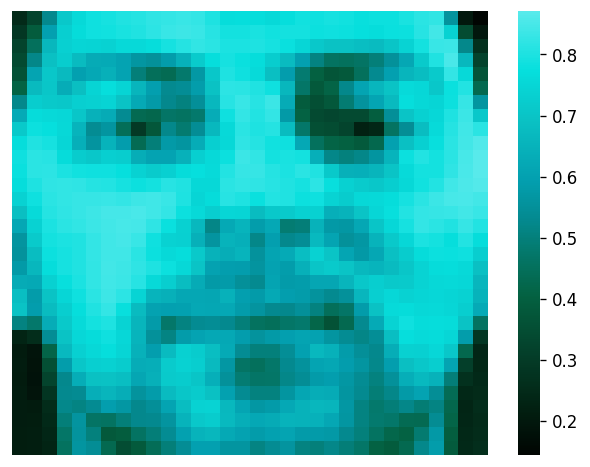

In [118]:
print_img(X_resized[67])

## 2. Обратимые слои

В аддитивном coupling-слое $y_1=x_1$, $y_2=x_2+m_\theta(x_1)$.
Обратный ход: $x_2=y_2-m_\theta(y_1)$, поэтому обращать MLP не нужно.
Якобиан треугольный с единицами на диагонали: $\det J=1$.
Чередуем неизменяемую координату в восьми слоях и добавляем обучаемый масштаб:

$$z=f_\theta(x)=e^s\odot g_\theta(x),\qquad
\log|\det J_f(x)|=s_1+s_2.$$

При $p_Z=\mathcal N(0,I_2)$ формула замены переменных даёт

$$\log p_\theta(x)=-\tfrac12\sum_{j=1}^2(z_j^2+\log 2\pi)+\sum_{j=1}^2s_j.$$

Минимизируем среднюю **NLL**: $-\log p_\theta(x)$; единицы — нат на точку.

In [119]:
class AdditiveCoupling(nn.Module):
    def __init__(self, keep, n, hidden_features=100):
        super().__init__()
        self.keep = keep
        n_from = (n + 1 - keep) // 2
        n_to = n - n_from

        self.net = nn.Sequential(nn.Linear(n_from, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, n_to))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x, inverse=False):
        x_from = x[:, self.keep::2]
        y = x.clone()
        y[:, 1 - self.keep::2] += (-1 if inverse else 1) * self.net(x_from)
        return y


class NICE(nn.Module):
    def __init__(self, n, layers=8, hidden_features=100):
        super().__init__()
        self.n = n
        self.layers = nn.ModuleList([
            AdditiveCoupling(i % 2, n, hidden_features) for i in range(layers)
        ])
        self.log_scale = nn.Parameter(torch.zeros(n))

    def forward(self, x):  # Данные -> латентное пространство.
        for layer in self.layers:
            x = layer(x)
        z = x * self.log_scale.exp()
        log_det = self.log_scale.sum().expand(z.shape[0])
        return z, log_det

    def inverse(self, z):  # Латентное пространство -> данные.
        x = z * (-self.log_scale).exp()
        for layer in reversed(self.layers):
            x = layer(x, inverse=True)
        return x

    def log_prob(self, x):
        z, log_det = self(x)
        log_base = -0.5 * (z.square() + math.log(2 * math.pi)).sum(dim=1)
        return log_base + log_det

    @torch.no_grad()
    def sample(self, batch_size):
        return self.inverse(torch.randn(batch_size, self.n, device=self.log_scale.device))


model = NICE(IMG[0] * IMG[1], hidden_features=400)

In [120]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params}")

Total params: 7134720


## 3. Обучение максимальным правдоподобием

Adam обновляет MLP и общий масштаб. Проверочная выборка используется только для наблюдения за качеством. Сравним NLL до и после обучения: меньше — лучше.

(100, -812.697509765625, -735.529296875)
(200, -1007.0827026367188, -918.826171875)
(300, -1097.57470703125, -997.6652221679688)
(400, -1182.660888671875, -1055.565185546875)
(500, -1253.137451171875, -1105.280517578125)
(600, -1314.475830078125, -1141.489013671875)
(700, -1366.156982421875, -1170.5355224609375)
(800, -1419.2872314453125, -1194.696044921875)
(900, -1454.560791015625, -1216.4337158203125)
(1000, -1497.6978759765625, -1225.50927734375)
(1100, -1525.01513671875, -1228.5120849609375)
(1200, -1569.4864501953125, -1243.6683349609375)
Обучение: 191.4 с; 1200 шагов
NLL (val): 10185.193 -> -1243.668 нат/точку


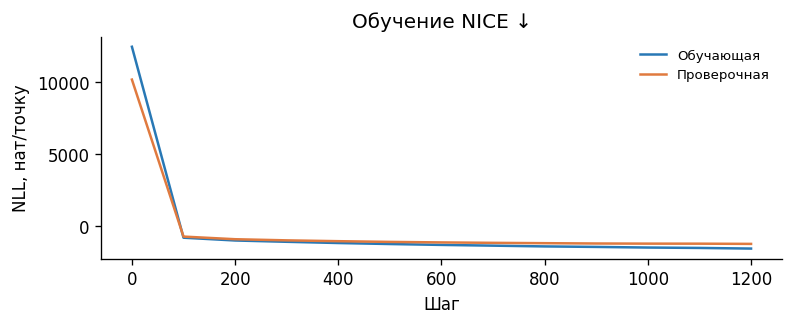

In [121]:
TRAIN_SIZE = 300
x_train, x_val = X_resized[:TRAIN_SIZE].flatten(1), X_resized[TRAIN_SIZE:].flatten(1)

optimizer = torch.optim.Adam([
    {"params": model.layers.parameters(), "lr": 1e-4},
    {"params": [model.log_scale], "lr": 1e-3},
])
history = []

@torch.no_grad()
def record(step):
    history.append((step, -model.log_prob(x_train).mean().item(),
                         -model.log_prob(x_val).mean().item()))

# Ставим масштабы сразу примерно правильными
with torch.no_grad():
       model.log_scale.copy_(-x_train.std(0).clamp_min(1e-3).log())

record(0)
started = time.perf_counter()
model.train()
for step in range(1, STEPS + 1):
    batch = x_train[torch.randint(len(x_train), (BATCH_SIZE,))]
    loss = -model.log_prob(batch).mean()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()
    if step % STEP_RECORD == 0:
        record(step)
        print(history[-1])
model.eval()

print(f"Обучение: {time.perf_counter() - started:.1f} с; {STEPS} шагов")
print(f"NLL (val): {history[0][2]:.3f} -> {history[-1][2]:.3f} нат/точку")

h = np.array(history)
fig, ax = plt.subplots(figsize=(6.5, 2.6), layout="constrained")
ax.plot(h[:, 0], h[:, 1], label="Обучающая", color="#2878B5")
ax.plot(h[:, 0], h[:, 2], label="Проверочная", color="#E07A3F")
ax.set(xlabel="Шаг", ylabel="NLL, нат/точку", title="Обучение NICE ↓")
ax.legend(frameon=False, fontsize=8)
plt.show()

In [125]:
def print_imgs(images, ncols=5, size=1.6):
    images = [img.detach().cpu().numpy().reshape(IMG) for img in images]
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, img in zip(np.ravel(axes), images):
        sns.heatmap(img, ax=ax, cmap=not_human_cmap, cbar=False,
                    xticklabels=False, yticklabels=False, square=True)
    plt.tight_layout()
    plt.show()


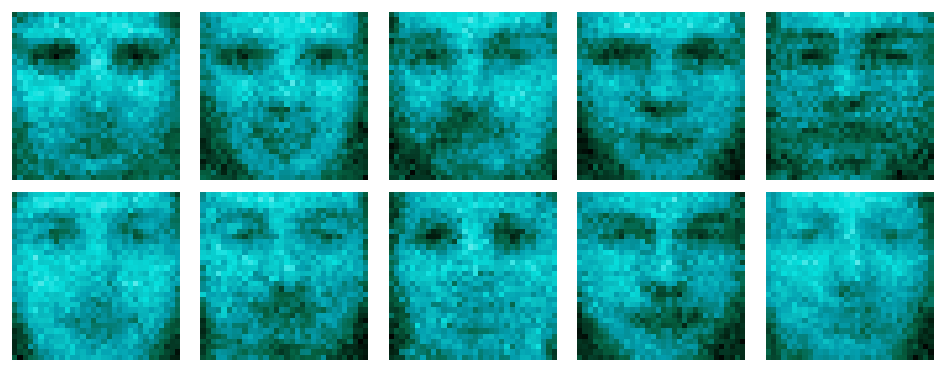

In [126]:
with torch.no_grad():
    # сдвигаем их ближе к нулю чтобы более вероятные(более реальные) картинки генерились
    generated = model.inverse(0.7 * torch.randn(10, model.n, device=model.log_scale.device))
print_imgs(generated)